In [2]:
import json
import torch
import joblib
import pandas as pd
import numpy as np
from pathlib import Path
from typing import Union
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from credit_risk.features import FEATURES_DIR, load_features
from credit_risk.evaluation import evaluate_model
from credit_risk.utils import to_jsonable
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score

2026-06-29 18:12:45.436 | INFO     | credit_risk.config:<module>:11 - PROJ_ROOT path is: /Users/ak007/SML/Credit-Risk-Default-Prediction-System


In [3]:
feature_splits = load_features()

2026-06-29 18:12:46.764 | INFO     | credit_risk.features:load_features:263 - Loading the processed features...
2026-06-29 18:12:47.229 | INFO     | credit_risk.features:load_features:270 - Loaded successfully!


In [4]:
X_train = feature_splits['train'][0].to_numpy()
y_train = feature_splits['train'][1].to_numpy().ravel()
X_val = feature_splits['val'][0].to_numpy()
y_val = feature_splits['val'][1].to_numpy().ravel()
X_test = feature_splits['test'][0].to_numpy()
y_test = feature_splits['test'][1].to_numpy().ravel()

In [5]:
class MLP(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: list[int] = [128, 64], dropout: float = 0.2):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dim:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = h
            
        layers.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.net(x).squeeze(-1)

In [6]:
def train_one_fold(X_train: np.array, y_train: np.array, X_val: np.array, n_epochs: int = 20, batch_size: int = 2048):
    """Train the MLP for one fold"""
    
    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    y_train_t = torch.from_numpy(y_train.astype(np.float32))
    X_val_t = torch.from_numpy(X_val.astype(np.float32))
    
    model = MLP(input_dim=X_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCEWithLogitsLoss()
    
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
    
    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0
        
        for xb, yb in loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        # print(f"Epoch {epoch}: loss={epoch_loss/len(loader):.4f}")
        
    # predict
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_t)
        val_proba = torch.sigmoid(val_logits).numpy()
        
    return val_proba

In [7]:
tscv = TimeSeriesSplit()

In [7]:
# CV
scores = []
i = 1
for train_idx, val_idx in tscv.split(X_train):
    val_proba = train_one_fold(
        X_train=X_train[train_idx],
        y_train=y_train[train_idx],
        X_val=X_train[val_idx],
        n_epochs=30
    )
    score = average_precision_score(y_train[val_idx], val_proba)
    scores.append(score)
    print(f"{i}th fold done...")
    i+=1
    
print("Mean PR-AUC:", np.mean(scores))

1th fold done...
2th fold done...
3th fold done...
4th fold done...
5th fold done...
Mean PR-AUC: 0.2972262497434327


In [8]:
scores

[0.24776060953735035,
 0.2806742271464163,
 0.3010709835131524,
 0.32744266752870044,
 0.32918276099154387]

In [8]:
def train_nn(X_train: np.array, y_train: np.array, n_epochs: int = 20, dropout: float = 0.2, batch_size: int = 2048, hidden_dim: list[int] = [128, 64]) -> Union[MLP, list[float]]:
    """trains the MLP model"""
    X_train_t = torch.from_numpy(X_train.astype(np.float32))
    y_train_t = torch.from_numpy(y_train.astype(np.float32))
    
    model = MLP(input_dim=X_train.shape[1], hidden_dim=hidden_dim, dropout=dropout)
    cost_fn = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    dataset = TensorDataset(X_train_t, y_train_t)
    loader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
    
    loss_track = []
    for epoch in range(n_epochs):
        epoch_cost = 0
        
        for xb, yb in loader:
            optimizer.zero_grad()
            
            # forward
            logits = model(xb)
            loss = cost_fn(logits, yb)
            
            # backward
            loss.backward()
            optimizer.step()
            epoch_cost += loss.item()
            
        loss_track.append(epoch_cost/len(loader))
        print(f"{epoch+1} epoch: avg loss per batch - {epoch_cost/len(loader)}")
        
    return model, loss_track

In [9]:
train_nn_model, loss_track = train_nn(
    X_train=X_train,
    y_train=y_train,
    n_epochs=30
)

1 epoch: avg loss per batch - 0.43427589012865436
2 epoch: avg loss per batch - 0.41821725457383874
3 epoch: avg loss per batch - 0.4164376244471784
4 epoch: avg loss per batch - 0.4155972673181902
5 epoch: avg loss per batch - 0.41441484357704195
6 epoch: avg loss per batch - 0.41361048137932493
7 epoch: avg loss per batch - 0.4131706381837527
8 epoch: avg loss per batch - 0.41240210347531137
9 epoch: avg loss per batch - 0.4117771257695399
10 epoch: avg loss per batch - 0.4114541897648259
11 epoch: avg loss per batch - 0.4110143572876328
12 epoch: avg loss per batch - 0.41076588709103434
13 epoch: avg loss per batch - 0.4101894811580056
14 epoch: avg loss per batch - 0.4097851388025702
15 epoch: avg loss per batch - 0.40951928979994956
16 epoch: avg loss per batch - 0.4091718247846553
17 epoch: avg loss per batch - 0.4087526152531306
18 epoch: avg loss per batch - 0.408339240049061
19 epoch: avg loss per batch - 0.4079844200035982
20 epoch: avg loss per batch - 0.4080908413518939
21 

In [10]:
X_train_t = torch.from_numpy(X_train.astype(np.float32))
X_val_t = torch.from_numpy(X_val.astype(np.float32))
X_test_t = torch.from_numpy(X_test.astype(np.float32))

In [11]:
train_nn_model.eval()
with torch.no_grad():
    train_proba = torch.sigmoid(train_nn_model(X_train_t)).numpy()
    val_proba = torch.sigmoid(train_nn_model(X_val_t)).numpy()
    test_proba = torch.sigmoid(train_nn_model(X_test_t)).numpy()

In [12]:
nn_eval_dict = evaluate_model(
    y_train=y_train,
    train_proba=train_proba,
    y_val=y_val,
    val_proba=val_proba,
    y_test=y_test,
    test_proba=test_proba,
    fn_cost=10000,
    fp_cost=2000
)

In [13]:
nn_eval_dict

{'threshold': np.float64(0.15000000000000002),
 'train': {'ROC-AUC': 0.7341504995744335,
  'PR-AUC': 0.3732955351342282,
  'brier_score': 0.12396682053804398,
  'precision': 0.2650129476985922,
  'recall': 0.749133320445905,
  'confusion_matrix': array([[227232, 161215],
         [ 19466,  58129]])},
 'val': {'ROC-AUC': 0.7057673433589793,
  'PR-AUC': 0.3402819975733838,
  'brier_score': 0.13800878822803497,
  'precision': 0.27310415637501334,
  'recall': 0.7307906639192359,
  'confusion_matrix': array([[192953, 150088],
         [ 20773,  56390]])},
 'test': {'ROC-AUC': 0.6920521080082956,
  'PR-AUC': 0.30323734332010566,
  'brier_score': 0.13119754195213318,
  'precision': 0.2524248448701729,
  'recall': 0.6906783153383335,
  'confusion_matrix': array([[210006, 148908],
         [ 22518,  50280]])}}

In [14]:
cwd = Path.cwd()
project_root = cwd.parent
nn_path = project_root / "models" / 'mlp'
nn_path.mkdir(parents=True, exist_ok=True)
xgb_path = project_root / 'models' / 'tuned_xgb'

In [15]:
np.save(nn_path / 'train_proba.npy', train_proba)
np.save(nn_path / 'val_proba.npy', val_proba)
np.save(nn_path / 'test_proba.npy', test_proba)

In [16]:
with open(xgb_path / 'metric.json', 'r') as f:
    xgb_eval_dict = json.load(f)

In [17]:
xgb_eval_dict

{'threshold': 0.16,
 'train': {'ROC-AUC': 0.7439300157154369,
  'PR-AUC': 0.381689819454631,
  'brier_score': 0.12316741794347763,
  'precision': 0.2783728747025197,
  'recall': 0.7311166956633803,
  'confusion_matrix': [[241383, 147064], [20864, 56731]]},
 'val': {'ROC-AUC': 0.708335490425068,
  'PR-AUC': 0.34885062650079623,
  'brier_score': 0.13714288175106049,
  'precision': 0.2789071369106183,
  'recall': 0.7163796119902025,
  'confusion_matrix': [[200124, 142917], [21885, 55278]]},
 'test': {'ROC-AUC': 0.6935841329758616,
  'PR-AUC': 0.3104578352376564,
  'brier_score': 0.13049693405628204,
  'precision': 0.2591251104930686,
  'recall': 0.6604027583175361,
  'confusion_matrix': [[221458, 137456], [24722, 48076]]}}

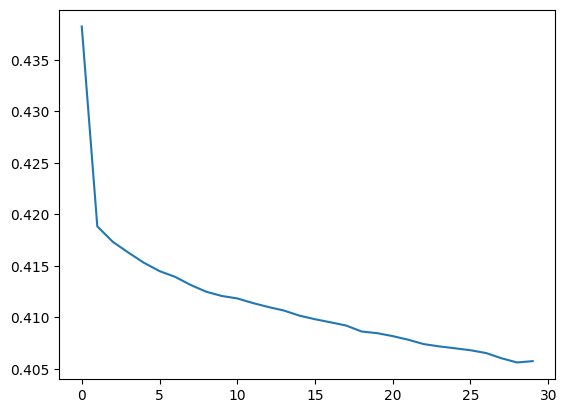

In [18]:
import matplotlib.pyplot as plt

plt.plot(loss_track)

In [19]:
nn_path = project_root / "models" / 'mlp'
nn_path.mkdir(parents=True, exist_ok=True)
torch.save(train_nn_model.state_dict(), nn_path / "model_state.pt")

In [20]:
arch = {
    "input_dim": X_train.shape[1],
    "hidden_dim": [128, 64],
    "dropout": 0.2,
    "batch_size": 2048
}

In [21]:
with open(nn_path / "architecture.json", "w") as f:
    json.dump(arch, f, indent=2)

In [22]:
training_info = {
    "n_epochs": 30,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "loss": "BCEWithLogitsLoss",
    "cv_mean_pr_auc": 0.298,
    "framework": "pytorch",
    "framework_version": torch.__version__,
}

with open(nn_path / "training_info.json", "w") as f:
    json.dump(training_info, f, indent=2)

In [23]:
with open(nn_path / "metrics.json", "w") as f:
    json.dump(to_jsonable(nn_eval_dict), f, indent=2)

In [24]:
with open(nn_path / "threshold.json", "w") as f:
    json.dump({"threshold": 0.15, "fn_cost": 10000, "fp_cost": 2000}, f, indent=2)

In [25]:
training_info["preprocessor_path"] = "data/processed/features/preprocessor.pkl"

In [26]:
with open(nn_path / "training_info.json", "w") as f:
    json.dump(training_info, f, indent=2)